In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries imported successfully")


Libraries imported successfully


In [3]:
# Load cleaned datasets

nav_df = pd.read_csv("../data/processed/cleaned_02_nav_history.csv")
benchmark_df = pd.read_csv("../data/processed/cleaned_10_benchmark_indices.csv")
fund_df = pd.read_csv("../data/processed/cleaned_01_fund_master.csv")

print("NAV data:", nav_df.shape)
print("Benchmark data:", benchmark_df.shape)
print("Fund master:", fund_df.shape)

NAV data: (46000, 3)
Benchmark data: (8050, 3)
Fund master: (40, 15)


In [4]:
print("NAV DATA")
display(nav_df.head())

print("BENCHMARK DATA")
display(benchmark_df.head())

print("FUND MASTER")
display(fund_df.head())

NAV DATA


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


BENCHMARK DATA


,date,index_name,close_value
0,2022-01-03,BSE_SMALLCAP,26554.60
1,2022-01-04,BSE_SMALLCAP,27079.92
2,2022-01-05,BSE_SMALLCAP,27313.35
3,2022-01-06,BSE_SMALLCAP,27377.05
4,2022-01-07,BSE_SMALLCAP,26316.86


FUND MASTER


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
1,100025,HDFC Mutual Fund,HDFC Short Term Debt Fund - Regular - Growth,Debt,Short Duration,Regular,2002-06-25,CRISIL Short Term Bond Index,0.56,0.5,500,1000,Anil Bamboli,Low,DC02
2,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02
3,101206,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.60,1.0,500,1000,Mahesh Patil,Moderate,EC01
4,101207,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-05-31,BSE 250 SmallCap TRI,1.53,1.0,500,1000,Mircea Ciobanu,Very High,EC03


In [5]:
print("NAV DATA TYPES")
print(nav_df.dtypes)

print("\nBENCHMARK DATA TYPES")
print(benchmark_df.dtypes)

print("\nFUND MASTER DATA TYPES")
print(fund_df.dtypes)

NAV DATA TYPES
amfi_code      int64
date             str
nav          float64
dtype: object

BENCHMARK DATA TYPES
date               str
index_name         str
close_value    float64
dtype: object

FUND MASTER DATA TYPES
amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object


In [6]:
# Convert date columns to datetime

nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

print("NAV date type:", nav_df["date"].dtype)
print("Benchmark date type:", benchmark_df["date"].dtype)

NAV date type: datetime64[us]
Benchmark date type: datetime64[us]


In [7]:
# Sort NAV data by fund and date

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print(nav_df.head())


   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [8]:
# Check number of unique schemes

number_of_schemes = nav_df["amfi_code"].nunique()

print("Number of schemes:", number_of_schemes)

Number of schemes: 40


In [9]:
# Check duplicate fund-date combinations

duplicates = nav_df.duplicated(
    subset=["amfi_code", "date"]
).sum()

print("Duplicate fund-date records:", duplicates)

Duplicate fund-date records: 0


In [10]:
# Calculate daily returns for each mutual fund scheme

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav_df.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [11]:
# Check daily return statistics

print("Daily return calculated successfully")
print("Missing daily returns:", nav_df["daily_return"].isna().sum())
print("Minimum daily return:", nav_df["daily_return"].min())
print("Maximum daily return:", nav_df["daily_return"].max())
print("Average daily return:", nav_df["daily_return"].mean())

Daily return calculated successfully
Missing daily returns: 40
Minimum daily return: -0.058102013949189124
Maximum daily return: 0.06471309359097144
Average daily return: 0.0006310517590547711


In [12]:
# Verify daily returns exist for all schemes

return_counts = nav_df.groupby("amfi_code")["daily_return"].count()

print("Number of schemes with daily returns:", return_counts.size)
print(return_counts.head())

Number of schemes with daily returns: 40
amfi_code
100016    1149
100025    1149
100033    1149
101206    1149
101207    1149
Name: daily_return, dtype: int64


In [13]:
# Basic statistics of daily returns

daily_returns = nav_df["daily_return"].dropna()

print(daily_returns.describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [14]:
# Check extreme daily returns

print("Returns below -10%:", (daily_returns < -0.10).sum())
print("Returns above +10%:", (daily_returns > 0.10).sum())

Returns below -10%: 0
Returns above +10%: 0


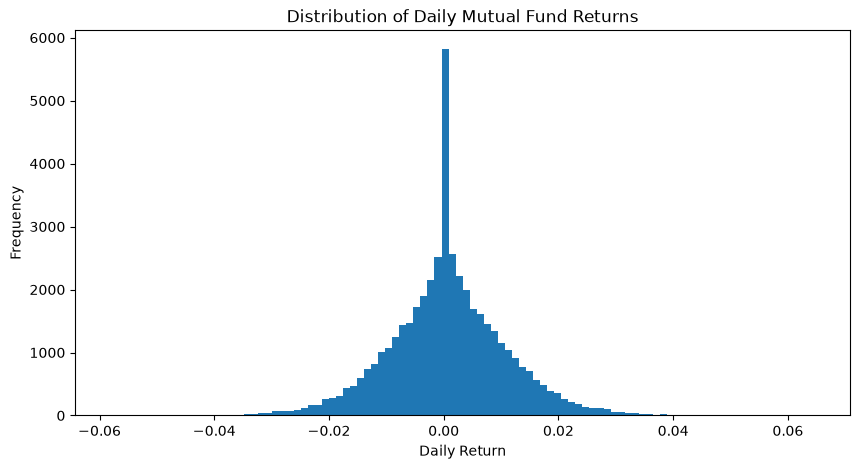

In [15]:
# Plot daily return distribution

plt.figure(figsize=(10, 5))

plt.hist(daily_returns, bins=100)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

### Daily Return Distribution Validation

Daily returns were calculated separately for all 40 mutual fund schemes. The distribution was examined using descriptive statistics and a histogram. Most daily returns are expected to remain close to zero, while extreme positive or negative observations are relatively uncommon. The distribution was reviewed for unusual values before performing further performance calculations.

In [16]:
# Find the latest available NAV date

latest_date = nav_df["date"].max()

print("Latest NAV date:", latest_date)

Latest NAV date: 2026-05-29 00:00:00


In [17]:
def calculate_cagr(group, years, latest_date):
    """
    Calculate CAGR for one fund over the requested number of years.
    Uses the latest available NAV and the NAV closest to the target date.
    """

    end_date = group["date"].max()

    target_date = end_date - pd.DateOffset(years=years)

    # Find the NAV closest to the target date
    start_row = group.iloc[
        (group["date"] - target_date).abs().argsort()[:1]
    ]

    end_row = group.iloc[
        (group["date"] - end_date).abs().argsort()[:1]
    ]

    start_nav = start_row["nav"].iloc[0]
    end_nav = end_row["nav"].iloc[0]

    actual_years = (
        (end_row["date"].iloc[0] - start_row["date"].iloc[0]).days
        / 365.25
    )

    if start_nav <= 0 or actual_years <= 0:
        return np.nan

    cagr = (end_nav / start_nav) ** (1 / actual_years) - 1

    return cagr

In [18]:
# Calculate 1-year, 3-year and 5-year CAGR

cagr_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    result = {
        "amfi_code": amfi_code,
        "cagr_1yr": calculate_cagr(group, 1, latest_date),
        "cagr_3yr": calculate_cagr(group, 3, latest_date),
        "cagr_5yr": calculate_cagr(group, 5, latest_date)
    }

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.head())
print("\nNumber of funds:", len(cagr_df))

   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016 -0.022258  0.012924  0.026371
1     100025  0.037076  0.039155  0.044582
2     100033  0.532772  0.324340  0.301232
3     101206  0.479638  0.289602  0.235384
4     101207 -0.240003 -0.041515  0.079388

Number of funds: 40


In [19]:
# Add fund names and fund house information

cagr_df = cagr_df.merge(
    fund_df[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
]

display(cagr_df.head())

,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.022258,0.012924,0.026371
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,0.037076,0.039155,0.044582
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.532772,0.324340,0.301232
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.479638,0.289602,0.235384
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.240003,-0.041515,0.079388


In [20]:
print("1Y CAGR available:", cagr_df["cagr_1yr"].notna().sum())
print("3Y CAGR available:", cagr_df["cagr_3yr"].notna().sum())
print("5Y CAGR available:", cagr_df["cagr_5yr"].notna().sum())

1Y CAGR available: 40
3Y CAGR available: 40
5Y CAGR available: 40


In [21]:
display(
    cagr_df.sort_values(
        "cagr_3yr",
        ascending=False
    ).reset_index(drop=True)
)

,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr,cagr_5yr
0,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.222779,0.351025,0.282144
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.203760,0.339920,0.309741
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.130738,0.324789,0.232951
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.532772,0.324340,0.301232
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.296277,0.317692,0.328274
5,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.604893,0.304486,0.258047
6,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.266776,0.295751,0.309075
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.397838,0.291714,0.319495
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.479638,0.289602,0.235384
9,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.651955,0.269935,0.322874


In [22]:
# Calculate annualized Sharpe Ratio

risk_free_rate = 0.065
daily_risk_free_rate = (1 + risk_free_rate) ** (1 / 252) - 1

sharpe_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1 and returns.std() != 0:

        annualized_return = returns.mean() * 252
        annualized_std = returns.std() * np.sqrt(252)

        sharpe = (
            annualized_return - risk_free_rate
        ) / annualized_std

    else:
        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

print(sharpe_df.head())
print("\nNumber of funds:", len(sharpe_df))

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661

Number of funds: 40


In [23]:
# Add fund information to Sharpe results

sharpe_df = sharpe_df.merge(
    fund_df[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

sharpe_df = sharpe_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "sharpe_ratio"
    ]
]

display(sharpe_df.head())

,amfi_code,scheme_name,fund_house,category,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.201517
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,-0.567095
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.093699
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.027213
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.162661


In [24]:
# Rank funds by Sharpe Ratio

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
)

display(sharpe_df)

,amfi_code,scheme_name,fund_house,category,sharpe_ratio,sharpe_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,1.448291,1.0
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,1.306744,2.0
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,1.234930,3.0
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.208267,4.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,1.180101,5.0
5,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,1.132122,6.0
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.093699,7.0
7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,1.081659,8.0
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.027213,9.0
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,1.026524,10.0


In [25]:
print(
    "Funds with valid Sharpe Ratio:",
    sharpe_df["sharpe_ratio"].notna().sum()
)

print(
    "Funds with missing Sharpe Ratio:",
    sharpe_df["sharpe_ratio"].isna().sum()
)

Funds with valid Sharpe Ratio: 40
Funds with missing Sharpe Ratio: 0


In [26]:
# Calculate annualized Sortino Ratio

sortino_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # Downside returns only
    downside_returns = returns[returns < 0]

    if len(returns) > 1 and len(downside_returns) > 1:

        annualized_return = returns.mean() * 252

        downside_std = downside_returns.std() * np.sqrt(252)

        if downside_std != 0:
            sortino = (
                annualized_return - risk_free_rate
            ) / downside_std
        else:
            sortino = np.nan

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

print(sortino_df.head())
print("\nNumber of funds:", len(sortino_df))

   amfi_code  sortino_ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644

Number of funds: 40


In [27]:
# Add fund information

sortino_df = sortino_df.merge(
    fund_df[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "sortino_ratio"
    ]
]

display(sortino_df.head())

,amfi_code,scheme_name,fund_house,category,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.351047
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,-0.941821
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.829134
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.799563
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.276644


In [28]:
# Rank funds by Sortino Ratio

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["sortino_rank"] = (
    sortino_df["sortino_ratio"]
    .rank(ascending=False, method="min")
)

display(sortino_df)

,amfi_code,scheme_name,fund_house,category,sortino_ratio,sortino_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,2.385644,1.0
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,2.364320,2.0
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,2.146914,3.0
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,2.140267,4.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,2.029353,5.0
5,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,1.875101,6.0
6,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,1.850133,7.0
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.829134,8.0
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,1.805294,9.0
9,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.799563,10.0


In [29]:
print(
    "Funds with valid Sortino Ratio:",
    sortino_df["sortino_ratio"].notna().sum()
)

print(
    "Funds with missing Sortino Ratio:",
    sortino_df["sortino_ratio"].isna().sum()
)

print(
    "\nBest Sortino Ratio:",
    sortino_df["sortino_ratio"].max()
)

print(
    "Worst Sortino Ratio:",
    sortino_df["sortino_ratio"].min()
)

Funds with valid Sortino Ratio: 40
Funds with missing Sortino Ratio: 0

Best Sortino Ratio: 2.3856443733688186
Worst Sortino Ratio: -1.681037866751281


In [30]:
# Check available benchmark indices

print(
    benchmark_df["index_name"]
    .value_counts()
)

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: count, dtype: int64


In [31]:
# Prepare NIFTY100 benchmark data

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date").reset_index(drop=True)

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print("NIFTY100 records:", len(nifty100))
display(nifty100.head())

NIFTY100 records: 1150


,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY100,17778.24,NaN
1,2022-01-04,NIFTY100,17537.52,-0.013540
2,2022-01-05,NIFTY100,17607.73,0.004003
3,2022-01-06,NIFTY100,17556.05,-0.002935
4,2022-01-07,NIFTY100,17664.02,0.006150


In [32]:
# Check NIFTY100 return statistics

print(
    nifty100["benchmark_return"]
    .dropna()
    .describe()
)

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64


In [33]:
# Keep only date and benchmark return

benchmark_returns = nifty100[
    ["date", "benchmark_return"]
].dropna()

print("Benchmark return records:", len(benchmark_returns))
display(benchmark_returns.head())

Benchmark return records: 1149


,date,benchmark_return
1,2022-01-04,-0.013540
2,2022-01-05,0.004003
3,2022-01-06,-0.002935
4,2022-01-07,0.006150
5,2022-01-10,-0.008351


In [34]:
# Calculate Alpha and Beta for all 40 funds

alpha_beta_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    fund_returns = group[
        ["date", "daily_return"]
    ].dropna()

    # Match fund returns with NIFTY100 returns by date
    merged = fund_returns.merge(
        benchmark_returns,
        on="date",
        how="inner"
    )

    if len(merged) >= 30:

        regression = stats.linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope
        daily_alpha = regression.intercept
        annualized_alpha = daily_alpha * 252

    else:
        beta = np.nan
        annualized_alpha = np.nan

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": annualized_alpha,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print("Number of funds:", len(alpha_beta_df))
display(alpha_beta_df.head())

Number of funds: 40


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [35]:
# Add fund information

alpha_beta_df = alpha_beta_df.merge(
    fund_df[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

alpha_beta_df = alpha_beta_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "alpha",
        "beta"
    ]
]

display(alpha_beta_df.head())

,amfi_code,scheme_name,fund_house,category,alpha,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.108971,-0.065289


In [36]:
# Rank funds by Alpha

alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False, method="min")
)

display(
    alpha_beta_df.sort_values(
        "alpha",
        ascending=False
    ).reset_index(drop=True)
)

,amfi_code,scheme_name,fund_house,category,alpha,beta,alpha_rank
0,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.303370,-0.023196,1.0
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.300579,0.011455,2.0
2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.292636,0.000549,3.0
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.282704,0.018134,4.0
4,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.273305,-0.022830,5.0
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.271954,0.005104,6.0
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.269838,0.023684,7.0
7,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.265986,-0.002523,8.0
8,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.260767,-0.066265,9.0
9,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.232010,-0.031751,10.0


In [37]:
print(
    "Valid Alpha values:",
    alpha_beta_df["alpha"].notna().sum()
)

print(
    "Valid Beta values:",
    alpha_beta_df["beta"].notna().sum()
)

print(
    "Missing Alpha values:",
    alpha_beta_df["alpha"].isna().sum()
)

print(
    "Missing Beta values:",
    alpha_beta_df["beta"].isna().sum()
)

Valid Alpha values: 40
Valid Beta values: 40
Missing Alpha values: 0
Missing Beta values: 0


In [38]:
# Calculate Maximum Drawdown for all 40 funds

drawdown_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Maximum drawdown
    max_drawdown = group["drawdown"].min()

    # Date of maximum drawdown
    max_dd_row = group.loc[
        group["drawdown"].idxmin()
    ]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_drawdown,
        "max_drawdown_date": max_dd_row["date"]
    })

drawdown_df = pd.DataFrame(drawdown_results)

print("Number of funds:", len(drawdown_df))
display(drawdown_df.head())

Number of funds: 40


,amfi_code,max_drawdown,max_drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [39]:
# Add fund information

drawdown_df = drawdown_df.merge(
    fund_df[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

drawdown_df = drawdown_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "max_drawdown",
        "max_drawdown_date"
    ]
]

display(drawdown_df.head())

,amfi_code,scheme_name,fund_house,category,max_drawdown,max_drawdown_date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.247344,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,-0.043083,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,-0.162172,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.112916,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.354469,2026-05-11


In [40]:
# Rank funds by maximum drawdown
# Higher (less negative) drawdown gets a better rank

drawdown_df["max_dd_rank"] = (
    drawdown_df["max_drawdown"]
    .rank(ascending=False, method="min")
)

display(
    drawdown_df.sort_values(
        "max_drawdown",
        ascending=False
    ).reset_index(drop=True)
)

,amfi_code,scheme_name,fund_house,category,max_drawdown,max_drawdown_date,max_dd_rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Debt,-0.000977,2025-10-20,1.0
1,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Debt,-0.001163,2024-04-30,2.0
2,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt,-0.001622,2023-09-12,3.0
3,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,-0.043083,2023-07-28,4.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,-0.043287,2025-04-01,5.0
5,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Debt,-0.083164,2024-02-09,6.0
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,-0.108599,2022-03-29,7.0
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,-0.112657,2023-10-20,8.0
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.112916,2023-07-05,9.0
9,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity,-0.116506,2022-06-09,10.0


In [41]:
# Find the fund with the worst maximum drawdown

worst_dd = drawdown_df.loc[
    drawdown_df["max_drawdown"].idxmin()
]

print("Worst Maximum Drawdown Fund:")
print("Fund:", worst_dd["scheme_name"])
print("AMFI Code:", worst_dd["amfi_code"])
print(
    "Maximum Drawdown:",
    worst_dd["max_drawdown"]
)
print(
    "Drawdown Date:",
    worst_dd["max_drawdown_date"]
)

Worst Maximum Drawdown Fund:
Fund: SBI Small Cap Fund - Direct Plan - Growth
AMFI Code: 119599
Maximum Drawdown: -0.5257422117012851
Drawdown Date: 2025-10-28 00:00:00


In [42]:
def get_max_drawdown_period(group):
    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    trough_idx = group["drawdown"].idxmin()
    trough_row = group.loc[trough_idx]

    peak_nav = trough_row["running_max"]

    peak_rows = group[
        group["nav"] == peak_nav
    ]

    peak_row = peak_rows[
        peak_rows["date"] <= trough_row["date"]
    ].iloc[-1]

    return {
        "max_drawdown": trough_row["drawdown"],
        "peak_date": peak_row["date"],
        "trough_date": trough_row["date"],
        "peak_nav": peak_row["nav"],
        "trough_nav": trough_row["nav"]
    }

In [43]:
max_dd_periods = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    result = get_max_drawdown_period(group)

    result["amfi_code"] = amfi_code

    max_dd_periods.append(result)

max_dd_period_df = pd.DataFrame(max_dd_periods)

max_dd_period_df = max_dd_period_df.merge(
    fund_df[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

max_dd_period_df = max_dd_period_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "max_drawdown",
        "peak_date",
        "trough_date",
        "peak_nav",
        "trough_nav"
    ]
]

display(
    max_dd_period_df.sort_values(
        "max_drawdown"
    ).head(10)
)

,amfi_code,scheme_name,fund_house,category,max_drawdown,peak_date,trough_date,peak_nav,trough_nav
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,-0.525742,2023-01-17,2025-10-28,165.7647,78.6152
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,-0.516778,2025-05-22,2026-05-11,106.8214,51.6185
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.354469,2024-11-21,2026-05-11,80.3517,51.8695
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,-0.311719,2024-05-03,2025-01-03,174.4645,120.0806
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,-0.287060,2024-08-28,2025-05-14,225.2452,160.5863
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-0.280011,2025-01-07,2026-04-27,169.8164,122.2659
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.247344,2022-03-30,2022-09-15,546.3002,411.1759
29,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity,-0.240035,2023-11-09,2024-10-17,80.0837,60.8608
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,-0.233449,2025-04-09,2026-02-20,126.7224,97.1392
15,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Equity,-0.217514,2022-02-24,2023-05-22,42.2166,33.0339


### Maximum Drawdown Analysis

Maximum drawdown was calculated for each mutual fund scheme by comparing the NAV with its running historical maximum. The largest negative drawdown represents the maximum decline from a previous peak. The analysis also identifies the peak date and subsequent trough date associated with the worst drawdown period for each scheme.

In [44]:
# Combine all performance metrics

scorecard_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "cagr_3yr"
    ]
].copy()

scorecard_df = scorecard_df.merge(
    sharpe_df[
        ["amfi_code", "sharpe_ratio"]
    ],
    on="amfi_code",
    how="left"
)

scorecard_df = scorecard_df.merge(
    alpha_beta_df[
        ["amfi_code", "alpha", "beta"]
    ],
    on="amfi_code",
    how="left"
)

scorecard_df = scorecard_df.merge(
    drawdown_df[
        ["amfi_code", "max_drawdown"]
    ],
    on="amfi_code",
    how="left"
)

scorecard_df = scorecard_df.merge(
    fund_df[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

print("Scorecard rows:", len(scorecard_df))
display(scorecard_df.head())

Scorecard rows: 40


,amfi_code,scheme_name,fund_house,category,cagr_3yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,0.012924,-0.201517,0.037476,-0.058268,-0.247344,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,0.039155,-0.567095,0.042818,0.001158,-0.043083,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.324340,1.093699,0.271954,0.005104,-0.162172,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.289602,1.027213,0.213998,0.021086,-0.112916,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.041515,0.162661,0.108971,-0.065289,-0.354469,1.53


In [45]:
# Create performance ranks

scorecard_df["cagr_3yr_rank"] = (
    scorecard_df["cagr_3yr"]
    .rank(ascending=False, method="min")
)

scorecard_df["sharpe_rank"] = (
    scorecard_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
)

scorecard_df["alpha_rank"] = (
    scorecard_df["alpha"]
    .rank(ascending=False, method="min")
)

# Lower expense ratio is better
scorecard_df["expense_rank"] = (
    scorecard_df["expense_ratio_pct"]
    .rank(ascending=True, method="min")
)

# Less negative maximum drawdown is better
scorecard_df["max_dd_rank"] = (
    scorecard_df["max_drawdown"]
    .rank(ascending=False, method="min")
)

display(
    scorecard_df[
        [
            "scheme_name",
            "cagr_3yr_rank",
            "sharpe_rank",
            "alpha_rank",
            "expense_rank",
            "max_dd_rank"
        ]
    ].head()
)

,scheme_name,cagr_3yr_rank,sharpe_rank,alpha_rank,expense_rank,max_dd_rank
0,HDFC Top 100 Fund - Regular Plan - Growth,35.0,35.0,39.0,32.0,34.0
1,HDFC Short Term Debt Fund - Regular - Growth,34.0,39.0,38.0,2.0,4.0
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4.0,7.0,6.0,16.0,20.0
3,ABSL Frontline Equity Fund - Regular - Growth,9.0,9.0,12.0,36.0,9.0
4,ABSL Small Cap Fund - Regular - Growth,39.0,28.0,27.0,28.0,38.0


In [46]:
# Convert ranks to 0-100 scores

N = len(scorecard_df)

def rank_to_score(rank, n):
    if pd.isna(rank):
        return np.nan

    if n <= 1:
        return 100

    return 100 * (n - rank) / (n - 1)


scorecard_df["cagr_score"] = scorecard_df[
    "cagr_3yr_rank"
].apply(lambda x: rank_to_score(x, N))

scorecard_df["sharpe_score"] = scorecard_df[
    "sharpe_rank"
].apply(lambda x: rank_to_score(x, N))

scorecard_df["alpha_score"] = scorecard_df[
    "alpha_rank"
].apply(lambda x: rank_to_score(x, N))

scorecard_df["expense_score"] = scorecard_df[
    "expense_rank"
].apply(lambda x: rank_to_score(x, N))

scorecard_df["max_dd_score"] = scorecard_df[
    "max_dd_rank"
].apply(lambda x: rank_to_score(x, N))

display(
    scorecard_df[
        [
            "scheme_name",
            "cagr_score",
            "sharpe_score",
            "alpha_score",
            "expense_score",
            "max_dd_score"
        ]
    ].head()
)

,scheme_name,cagr_score,sharpe_score,alpha_score,expense_score,max_dd_score
0,HDFC Top 100 Fund - Regular Plan - Growth,12.820513,12.820513,2.564103,20.512821,15.384615
1,HDFC Short Term Debt Fund - Regular - Growth,15.384615,2.564103,5.128205,97.435897,92.307692
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.307692,84.615385,87.179487,61.538462,51.282051
3,ABSL Frontline Equity Fund - Regular - Growth,79.487179,79.487179,71.794872,10.256410,79.487179
4,ABSL Small Cap Fund - Regular - Growth,2.564103,30.769231,33.333333,30.769231,5.128205


In [47]:
# Calculate final 0-100 Fund Score

scorecard_df["fund_score"] = (
    0.30 * scorecard_df["cagr_score"]
    + 0.25 * scorecard_df["sharpe_score"]
    + 0.20 * scorecard_df["alpha_score"]
    + 0.15 * scorecard_df["expense_score"]
    + 0.10 * scorecard_df["max_dd_score"]
)

scorecard_df = scorecard_df.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

scorecard_df["overall_rank"] = (
    scorecard_df["fund_score"]
    .rank(ascending=False, method="min")
)

display(
    scorecard_df[
        [
            "overall_rank",
            "scheme_name",
            "cagr_3yr",
            "sharpe_ratio",
            "alpha",
            "expense_ratio_pct",
            "max_drawdown",
            "fund_score"
        ]
    ]
)

,overall_rank,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
0,1.0,Mirae Asset Large Cap Fund - Regular - Growth,0.339920,1.448291,0.269838,1.46,-0.112657,85.897436
1,2.0,ICICI Pru Midcap Fund - Regular - Growth,0.317692,1.180101,0.292636,1.36,-0.181885,81.794872
2,3.0,Kotak Flexicap Fund - Regular - Growth,0.295751,1.306744,0.273305,1.45,-0.129740,81.538462
3,4.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324340,1.093699,0.271954,1.38,-0.162172,80.641026
4,5.0,ICICI Pru Bluechip Fund - Direct - Growth,0.324789,1.026524,0.211948,0.80,-0.125883,79.487179
5,6.0,Axis Midcap Fund - Regular - Growth,0.351025,0.998231,0.260767,1.38,-0.209609,76.794872
6,7.0,SBI Bluechip Fund - Regular Plan - Growth,0.304486,1.208267,0.232010,1.54,-0.150124,74.358974
7,8.0,Mirae Asset Tax Saver Fund - Regular - Growth,0.291714,1.234930,0.282704,1.60,-0.163967,73.205128
8,9.0,ABSL Frontline Equity Fund - Regular - Growth,0.289602,1.027213,0.213998,1.60,-0.112916,67.564103
9,10.0,SBI Small Cap Fund - Regular Plan - Growth,0.266631,0.945308,0.303370,1.43,-0.287060,66.538462


In [48]:
print("Minimum Fund Score:", scorecard_df["fund_score"].min())
print("Maximum Fund Score:", scorecard_df["fund_score"].max())

print("\nTop 5 Funds:")
display(
    scorecard_df[
        [
            "overall_rank",
            "scheme_name",
            "fund_score"
        ]
    ].head(5)
)

Minimum Fund Score: 12.179487179487179
Maximum Fund Score: 85.89743589743588

Top 5 Funds:


,overall_rank,scheme_name,fund_score
0,1.0,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
1,2.0,ICICI Pru Midcap Fund - Regular - Growth,81.794872
2,3.0,Kotak Flexicap Fund - Regular - Growth,81.538462
3,4.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.641026
4,5.0,ICICI Pru Bluechip Fund - Direct - Growth,79.487179


In [49]:
final_scorecard = scorecard_df[
    [
        "overall_rank",
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "cagr_3yr",
        "sharpe_ratio",
        "alpha",
        "beta",
        "expense_ratio_pct",
        "max_drawdown",
        "fund_score"
    ]
].copy()

display(final_scorecard.head(10))

,overall_rank,amfi_code,scheme_name,fund_house,category,cagr_3yr,sharpe_ratio,alpha,beta,expense_ratio_pct,max_drawdown,fund_score
0,1.0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.339920,1.448291,0.269838,0.023684,1.46,-0.112657,85.897436
1,2.0,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.317692,1.180101,0.292636,0.000549,1.36,-0.181885,81.794872
2,3.0,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.295751,1.306744,0.273305,-0.022830,1.45,-0.129740,81.538462
3,4.0,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.324340,1.093699,0.271954,0.005104,1.38,-0.162172,80.641026
4,5.0,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.324789,1.026524,0.211948,0.016232,0.80,-0.125883,79.487179
5,6.0,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.351025,0.998231,0.260767,-0.066265,1.38,-0.209609,76.794872
6,7.0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.304486,1.208267,0.232010,-0.031751,1.54,-0.150124,74.358974
7,8.0,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.291714,1.234930,0.282704,0.018134,1.60,-0.163967,73.205128
8,9.0,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.289602,1.027213,0.213998,0.021086,1.60,-0.112916,67.564103
9,10.0,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.266631,0.945308,0.303370,-0.023196,1.43,-0.287060,66.538462


In [50]:
# Save Fund Scorecard

final_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


In [51]:
# Get the top 5 funds from the scorecard

top_5_funds = final_scorecard.head(5).copy()

print("Top 5 Funds:")
display(
    top_5_funds[
        [
            "overall_rank",
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ]
)

Top 5 Funds:


,overall_rank,amfi_code,scheme_name,fund_score
0,1.0,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
1,2.0,120505,ICICI Pru Midcap Fund - Regular - Growth,81.794872
2,3.0,120843,Kotak Flexicap Fund - Regular - Growth,81.538462
3,4.0,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.641026
4,5.0,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.487179


In [52]:
# Prepare NIFTY50 and NIFTY100 benchmark data

nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

nifty50["benchmark_return"] = (
    nifty50["close_value"].pct_change()
)

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print("NIFTY50 records:", len(nifty50))
print("NIFTY100 records:", len(nifty100))

NIFTY50 records: 1150
NIFTY100 records: 1150


In [53]:
# Define the 3-year comparison period

analysis_end_date = nav_df["date"].max()

analysis_start_date = (
    analysis_end_date - pd.DateOffset(years=3)
)

print("Analysis start:", analysis_start_date)
print("Analysis end:", analysis_end_date)

Analysis start: 2023-05-29 00:00:00
Analysis end: 2026-05-29 00:00:00


In [54]:
# Calculate growth of 100 for NIFTY50 and NIFTY100

def prepare_benchmark_growth(df, start_date, end_date):
    
    temp = df[
        (df["date"] >= start_date) &
        (df["date"] <= end_date)
    ].copy()

    temp = temp.sort_values("date")

    first_value = temp["close_value"].iloc[0]

    temp["growth_100"] = (
        temp["close_value"] / first_value
    ) * 100

    return temp


nifty50_growth = prepare_benchmark_growth(
    nifty50,
    analysis_start_date,
    analysis_end_date
)

nifty100_growth = prepare_benchmark_growth(
    nifty100,
    analysis_start_date,
    analysis_end_date
)

print("NIFTY50 observations:", len(nifty50_growth))
print("NIFTY100 observations:", len(nifty100_growth))

NIFTY50 observations: 785
NIFTY100 observations: 785


In [55]:
# Calculate growth of 100 for the top 5 funds

fund_growth_data = {}

for _, fund in top_5_funds.iterrows():

    amfi_code = fund["amfi_code"]

    temp = nav_df[
        (nav_df["amfi_code"] == amfi_code) &
        (nav_df["date"] >= analysis_start_date) &
        (nav_df["date"] <= analysis_end_date)
    ].copy()

    temp = temp.sort_values("date")

    if len(temp) > 0:

        first_nav = temp["nav"].iloc[0]

        temp["growth_100"] = (
            temp["nav"] / first_nav
        ) * 100

        fund_growth_data[amfi_code] = temp

print(
    "Funds prepared:",
    len(fund_growth_data)
)

Funds prepared: 5


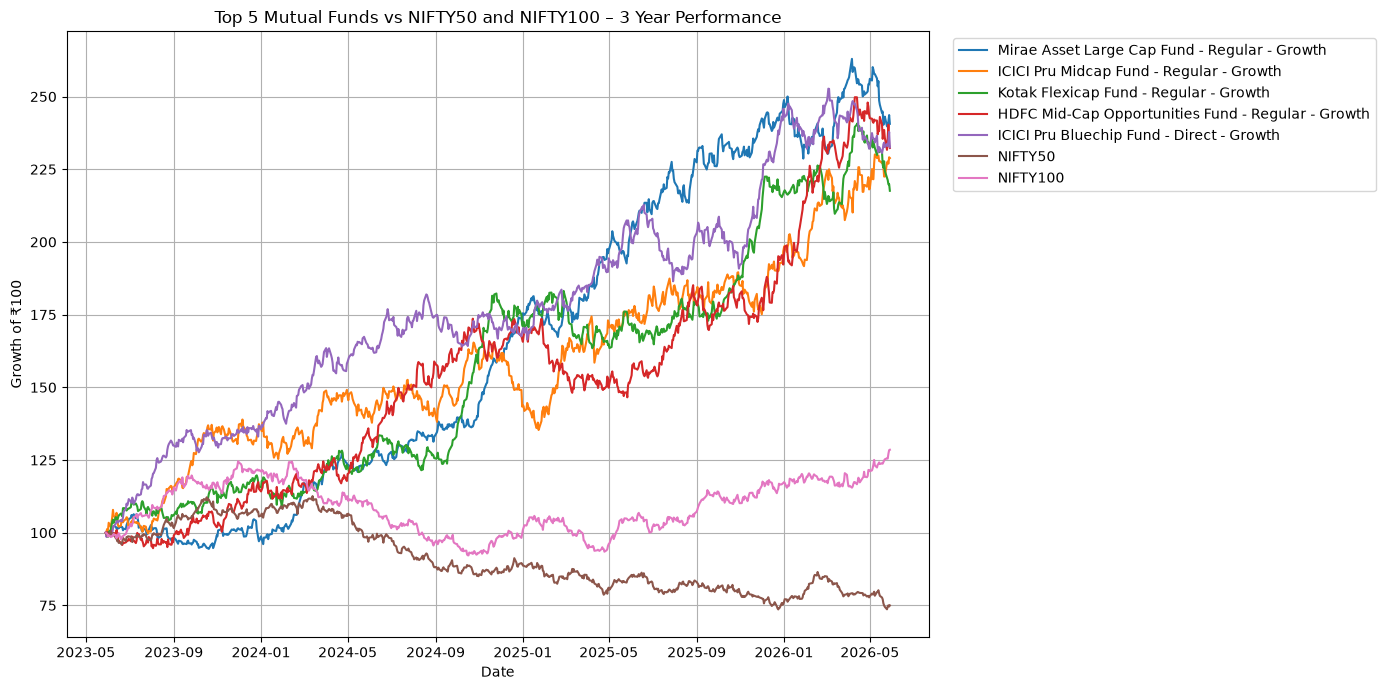

In [56]:
# Plot top 5 funds vs NIFTY50 and NIFTY100

plt.figure(figsize=(14, 7))

for _, fund in top_5_funds.iterrows():

    amfi_code = fund["amfi_code"]
    scheme_name = fund["scheme_name"]

    temp = fund_growth_data[amfi_code]

    plt.plot(
        temp["date"],
        temp["growth_100"],
        label=scheme_name
    )


plt.plot(
    nifty50_growth["date"],
    nifty50_growth["growth_100"],
    label="NIFTY50"
)

plt.plot(
    nifty100_growth["date"],
    nifty100_growth["growth_100"],
    label="NIFTY100"
)

plt.title(
    "Top 5 Mutual Funds vs NIFTY50 and NIFTY100 – 3 Year Performance"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.show()

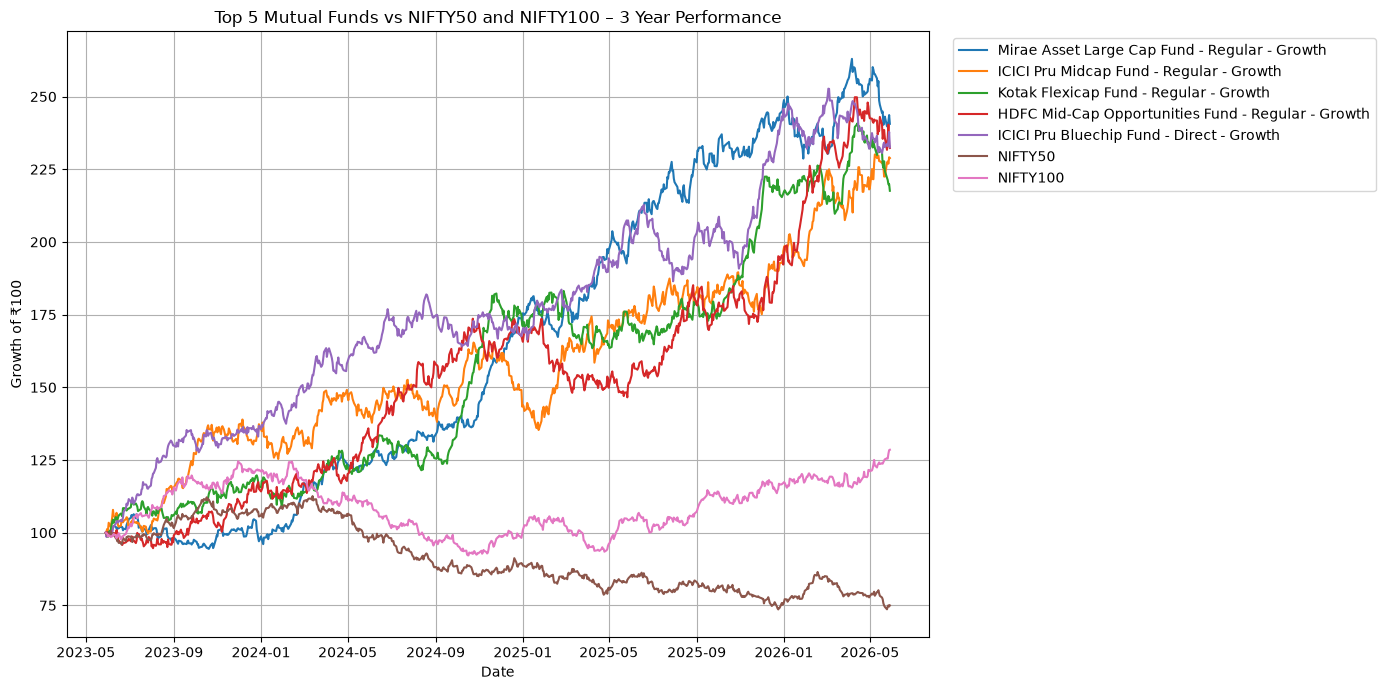

Benchmark comparison chart saved successfully


In [57]:
# Save benchmark comparison chart

plt.figure(figsize=(14, 7))

for _, fund in top_5_funds.iterrows():

    amfi_code = fund["amfi_code"]
    scheme_name = fund["scheme_name"]

    temp = fund_growth_data[amfi_code]

    plt.plot(
        temp["date"],
        temp["growth_100"],
        label=scheme_name
    )

plt.plot(
    nifty50_growth["date"],
    nifty50_growth["growth_100"],
    label="NIFTY50"
)

plt.plot(
    nifty100_growth["date"],
    nifty100_growth["growth_100"],
    label="NIFTY100"
)

plt.title(
    "Top 5 Mutual Funds vs NIFTY50 and NIFTY100 – 3 Year Performance"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Benchmark comparison chart saved successfully")

In [58]:
# Calculate tracking error against NIFTY100

tracking_error_results = []

benchmark_for_tracking = nifty100[
    (nifty100["date"] >= analysis_start_date) &
    (nifty100["date"] <= analysis_end_date)
][
    ["date", "benchmark_return"]
].dropna()

for _, fund in top_5_funds.iterrows():

    amfi_code = fund["amfi_code"]

    fund_returns = nav_df[
        (nav_df["amfi_code"] == amfi_code) &
        (nav_df["date"] >= analysis_start_date) &
        (nav_df["date"] <= analysis_end_date)
    ][
        ["date", "daily_return"]
    ].dropna()

    merged = fund_returns.merge(
        benchmark_for_tracking,
        on="date",
        how="inner"
    )

    if len(merged) > 1:

        active_returns = (
            merged["daily_return"]
            - merged["benchmark_return"]
        )

        tracking_error = (
            active_returns.std()
            * np.sqrt(252)
        )

    else:
        tracking_error = np.nan

    tracking_error_results.append({
        "amfi_code": amfi_code,
        "scheme_name": fund["scheme_name"],
        "tracking_error_nifty100": tracking_error
    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

display(tracking_error_df)

,amfi_code,scheme_name,tracking_error_nifty100
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.187867
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.232515
2,120843,Kotak Flexicap Fund - Regular - Growth,0.206410
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224838
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.187312


### Benchmark Comparison

The top five funds based on the composite Fund Score were compared with the NIFTY50 and NIFTY100 benchmarks over a three-year period. Growth of ₹100 was used to provide a common basis for comparing cumulative performance. Tracking error was also calculated against the NIFTY100 benchmark to measure the variability of the funds' active returns relative to the benchmark.

In [59]:
# Save Alpha and Beta results

final_alpha_beta = alpha_beta_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "alpha",
        "beta"
    ]
].copy()

final_alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully
